In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import nest_asyncio
nest_asyncio.apply()

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "vscode"            

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import matplotlib.dates as mdates
plt.style.use('ggplot')
params = {'legend.fontsize': 'medium',
        'figure.figsize': (18, 6),
        'axes.labelsize': 'medium',
        'axes.titlesize':'medium',
        'xtick.labelsize':'medium',
        'ytick.labelsize':'medium'}
pylab.rcParams.update(params)

import pandas as pd
import numpy as np
import rateslib as rl
import QuantLib as ql

import time
import datetime
import pytz

NYC_tz = pytz.timezone("America/New_York") 

import sys
sys.path.append("../../")

from RVUtils.plt_timeseries import make_secondary_axis_plot

C:\Users\chris\AppData\Local\Temp\ipykernel_11708\1746947010.py:27: LicenceNotice:


Rateslib is source-available (not open-source) software distributed under a dual-licence model.
No commercial licence is registered for this installation. Use is therefore permitted for non-commercial purposes only (at-home or university based academic use).
Any use in commercial, professional, or for-profit environments, including evaluation or trial use, requires a valid commercial licence or an approved evaluation licence.
Certain features may require a registered commercial or evaluation licence in current or future versions.
For licensing information or to register a licence, please visit: https://rateslib.com/licence



In [ ]:
from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP
from TB.IRSwapsTB import IRSwapsTB
from MDP.FixedRateBonds.FixedRateBondsMDP import FixedRateBondsMDP, _alias_to_cusip
from MDP.IRSwaptions.IRSwaptionMDP import IRSwaptionMDP
from TB.IRSwaptionsTB import IRSwaptionsTB
from TB.FixedRateBondsTB import FixedRateBondsTB
from Query.Unified.UnifiedQuery import UnifiedQuery
from Query.Unified.registry import UnifiedStructure, UnifiedValue
from TB.TimeseriesBuilder import TimeseriesBuilder

# Data-driven package weightings (PCA / regression / min-variance butterflies
# and curves). RVUtils is a namespace package, so the submodule has to be
# imported for `RVUtils.fly.<preset>` to resolve.
import RVUtils.fly

# curve_mdp = IRSwapsMDP(source="ERIS_EOD_LIVE-RL_BASIC")
curve_mdp = IRSwapsMDP(source="citivelo_excel_rl")
usts_mdp = FixedRateBondsMDP(source="USTS_FEDINVEST_WSJ_LIVE-RL")
vol_mdp = IRSwaptionMDP(
    source="CITIVELO-RL",
    curve_source="citivelo_excel_rl",
    request_defaults={"verify": False},
)

ts_builder = TimeseriesBuilder()

In [7]:
# tb = IRSwapsTB(IRSwapsMDP(source="eris_live_intraday"), show_tqdm=True, use_ts_cache=False)
# q  = UnifiedQuery(curve="USD-SOFR-1D", tenor="2y/10y", value=UnifiedValue.IRS_RATE)   # bare curve name
# df = TimeseriesBuilder().get_timeseries(
# 		start=NYC_tz.localize(datetime.datetime(2026,7,24,2,0)),
# 		end  =NYC_tz.localize(datetime.datetime(2026,7,24,17,00)),
# 		queries=[q], freq="1min", n_jobs=8, routers={"IRS": tb}, ignore_cache_miss=True)
# df

In [8]:
# plot, fig, ax, ax2, legend = make_secondary_axis_plot(engine="plotly")
# plot(df["USD-SOFR-1D 2y/5y CURVE RATE"], which="left")
# legend(show_date=True)
# plt.show()

In [ ]:
start = NYC_tz.localize(datetime.datetime(2025, 8, 1, 17, 00))
end = NYC_tz.localize(datetime.datetime(2026, 8, 14, 17, 00))
# start = datetime.date(2021, 1, 1)
# end = datetime.date(2026, 5, 11)

FLY = "1y5y/1y10y/1y30y"

df = ts_builder.get_timeseries(
    start=start,
    end=end,
    queries=[
		# UnifiedQuery(
        #     curve="USD-SOFR-1D",
        #     tenor="10y2y/12y3y/15y5y",
        #     value=UnifiedValue.IRS_RATE,
        # ),
        # ---- the plain 50-50 fly, weights (-1, +2, -1) -------------------------
        UnifiedQuery(
            curve="USD-SOFR-1D",
            tenor=FLY,
            value=UnifiedValue.IRS_RATE,
        ),
        # ---- directionality-hedged versions of the SAME fly --------------------
        # Each fetches the three legs as outrights, fits the weights from their
        # own history, and returns ONE column "<fly> FLY RATE [<preset>]".
        # The fitted weight paths land in df.attrs["fly_weights"].
        #
        # No window => ONE fit over the whole requested history. IN SAMPLE.
        UnifiedQuery(
            curve="USD-SOFR-1D",
            tenor=FLY,
            value=UnifiedValue.IRS_RATE,
            weighting=RVUtils.fly.pca_chgs,          # PC1-neutral (x_i / PC1_i), cov of daily changes
        ),
        # Rolling one month, refit every day - what you could actually have quoted.
        UnifiedQuery(
            curve="USD-SOFR-1D",
            tenor=FLY,
            value=UnifiedValue.IRS_RATE,
            weighting=RVUtils.fly.pca_chgs_1m,
        ),
        UnifiedQuery(
            curve="USD-SOFR-1D",
            tenor=FLY,
            value=UnifiedValue.IRS_RATE,
            weighting=RVUtils.fly.beta_chgs_1m,       # regress on wing curve + belly, trade the residual
        ),
        # PC1 AND PC2 neutral: belly pinned, wings solved so the package has
        # exactly zero exposure to level and slope. On a three-leg fly this is
        # the PC3 direction rescaled - verified live at (-1.0828, 2, -0.9836).
        UnifiedQuery(
            curve="USD-SOFR-1D",
            tenor=FLY,
            value=UnifiedValue.IRS_RATE,
            weighting=RVUtils.fly.pcaneutral_chgs_1m,
        ),
        UnifiedQuery(
            curve="USD-SOFR-1D",
            tenor=FLY,
            value=UnifiedValue.IRS_RATE,
            weighting=RVUtils.fly.minvar_chgs_1m,     # belly pinned at 2, wings minimise variance
        ),
        # Rich/cheap screen: today's fitted weights applied to the whole history.
        UnifiedQuery(
            curve="USD-SOFR-1D",
            tenor=FLY,
            value=UnifiedValue.IRS_RATE,
            weighting=RVUtils.fly.pca_chgs_1m_current,
        ),
        #
        # GRAMMAR:  {method}_{basis}[_{window}][_{modifier}...]
        #   method    pca         divide by the PC1 loading (level-neutral only)
        #             pca_proj    minimal-change PC-neutral projection
        #             pcaneutral  belly pinned, EXACTLY zero PC1 AND PC2 exposure
        #                         (aliases pca12, pc12; n_pc defaults to 2)
        #             beta        regress on wing curve + belly, trade the residual
        #             minvar      belly pinned, wings minimise variance
        #             base        the package's own -1/+2/-1
        #   basis     chgs | lvls
        #   window    (omit => one in-sample fit) | 1m 3m 6m 1y 2y | 45d | 21b | 250n | expanding
        #   modifier  lag1  weights knowable a day early (for backtests)
        #             level|pnl|current   how the weights become a series (default: auto)
        #             pc3   neutralise three components (needs 4+ legs)
        #             d5    weekly changes
        #             corr  correlation PCA          nc  uncentred (matches the SE pinv snippet)
        #             w     also emit the weight columns           legs  keep the leg columns
        # Or build one:  RVUtils.fly.weights(method="beta", basis="chgs", window="1m", lag=1)
        #
        # NOTE ON "level" vs "pnl": a hedged fly's weights do not sum to zero, so
        # sum(w_i * r_i) carries a rate-level term. Static weights make that a
        # constant offset; ROLLING weights make it wander, and on this data a
        # level-recombined 1m PCA fly runs ~180 bp/day of pure weight drift against
        # the plain fly's 0.8. So rolling presets default to "pnl" - the weights
        # held over each move - and static ones to "level". Override per preset.
		UnifiedQuery(
			curve="USD-SOFR-1D",
			selector={"shorthand":  "3Yx10Y", "strike": "ATMF"},
			structure=UnifiedStructure.IRSWAPTION_STRADDLE,
			value=UnifiedValue.IRSWAPTION_NVOL,
		)
        # UnifiedQuery(
		# 	cusip="CT2/CT10",
		# 	value=UnifiedValue.FRB_YTM,
        #   weighting=RVUtils.fly.beta_chgs_1m,
        # )
    ],
    n_jobs=12,
    routers={
        "IRS": IRSwapsTB(curve_mdp, show_tqdm=True),
        "FRB": FixedRateBondsTB(usts_mdp, show_tqdm=True),
        "IRSWAPTION":  IRSwaptionsTB(vol_mdp, show_tqdm=True),
    },
	# ignore_cache=True
)
df

In [ ]:
plot, fig, ax, ax2, legend = make_secondary_axis_plot(engine="plotly")
# plot(df["USD-SOFR-1D 10y2y/12y3y/15y5y FLY RATE"])
# plot(df["CT5/CT7 CURVE YTM"], which="left")
# plot(df["USD-SOFR-1D 5y/10y/30y FLY RATE"], which="left")
plot(df[f"USD-SOFR-1D {FLY} FLY RATE"], which="left")
plot(df[f"USD-SOFR-1D {FLY} FLY RATE [pca_chgs_1m]"], which="left")
plot(df[f"USD-SOFR-1D {FLY} FLY RATE [beta_chgs_1m]"], which="left")
plot(df["USD-SOFR-1D 3Yx10Y STRADDLE BUY ATMF NVOL"], which="right")
# plot(df["CT10/CT30 CURVE YTM"], which="right")
# plot(df["USD-SOFR-1D 10Y OUTRIGHT RATE"], which="right")
legend(show_date=True)
plt.show()

In [ ]:
# --- what the weighting actually did ------------------------------------------
# The fitted weight path per leg, and how much level-directionality each scheme
# removed. `beta_to_level` is |corr(d(fly), d(belly))| on daily changes - the
# thing the whole exercise is trying to kill.

WEIGHTED = [c for c in df.columns if "FLY RATE [" in c]

legs = df.attrs["fly_legs"][WEIGHTED[0]]
belly = legs.iloc[:, 1]

rows = []
for col in [f"USD-SOFR-1D {FLY} FLY RATE"] + WEIGHTED:
    d = pd.concat([df[col].diff(), belly.diff(), (legs.iloc[:, 2] - legs.iloc[:, 0]).diff()], axis=1).dropna()
    rows.append(
        {
            "series": col.split("FLY RATE")[-1].strip() or "(plain -1/+2/-1)",
            "n": len(d),
            "sd (bp/day)": d.iloc[:, 0].std(),
            "|corr| to belly": abs(np.corrcoef(d.iloc[:, 0], d.iloc[:, 1])[0, 1]),
            "|corr| to wing curve": abs(np.corrcoef(d.iloc[:, 0], d.iloc[:, 2])[0, 1]),
        }
    )
display(pd.DataFrame(rows).set_index("series").round(4))

# The weights themselves, e.g. for the rolling PCA fly.
w = df.attrs["fly_weights"][f"USD-SOFR-1D {FLY} FLY RATE [pca_chgs_1m]"]
display(w.dropna().tail())

fig_w = go.Figure()
for name in w.columns:
    fig_w.add_trace(go.Scatter(x=w.index, y=w[name], mode="lines", name=str(name)))
fig_w.update_layout(
    title="pca_chgs_1m: fitted leg weights (belly pinned at +2)",
    template="plotly_dark", height=420,
)
fig_w.show()

                                      OLS Regression Results                                     
Dep. Variable:     USD-SOFR-1D 1y5y/1y10y/1y30y FLY RATE   R-squared:                       0.322
Model:                                               OLS   Adj. R-squared:                  0.320
Method:                                    Least Squares   F-statistic:                     122.7
Date:                                   Sun, 16 Aug 2026   Prob (F-statistic):           1.40e-23
Time:                                           10:00:31   Log-Likelihood:                -593.73
No. Observations:                                    260   AIC:                             1191.
Df Residuals:                                        258   BIC:                             1199.
Df Model:                                              1                                         
Covariance Type:                               nonrobust                                         
                    

c:\Users\chris\clee\ARBS\notebooks\timeseries\../..\RVUtils\regression.py:859: UserWarning:

color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.



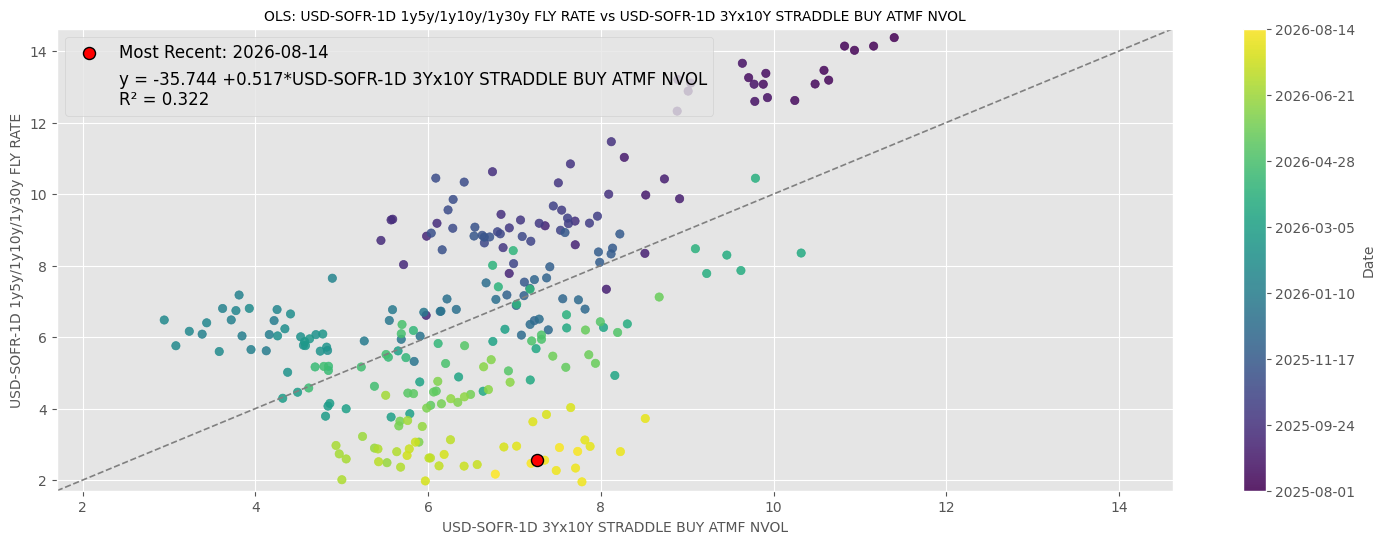

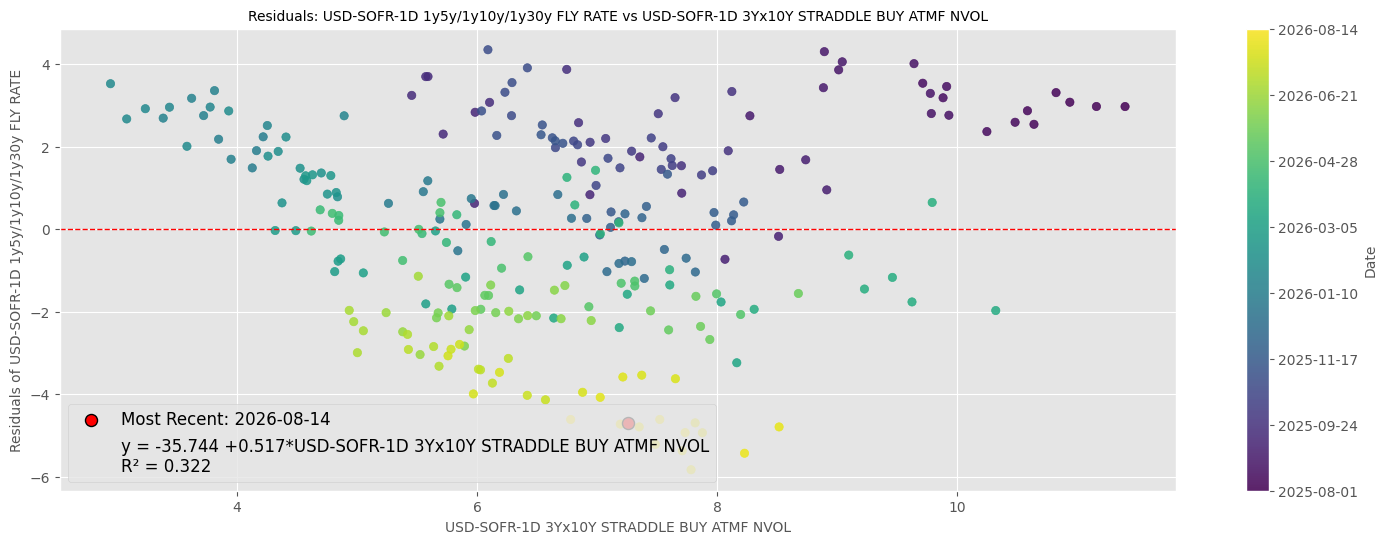

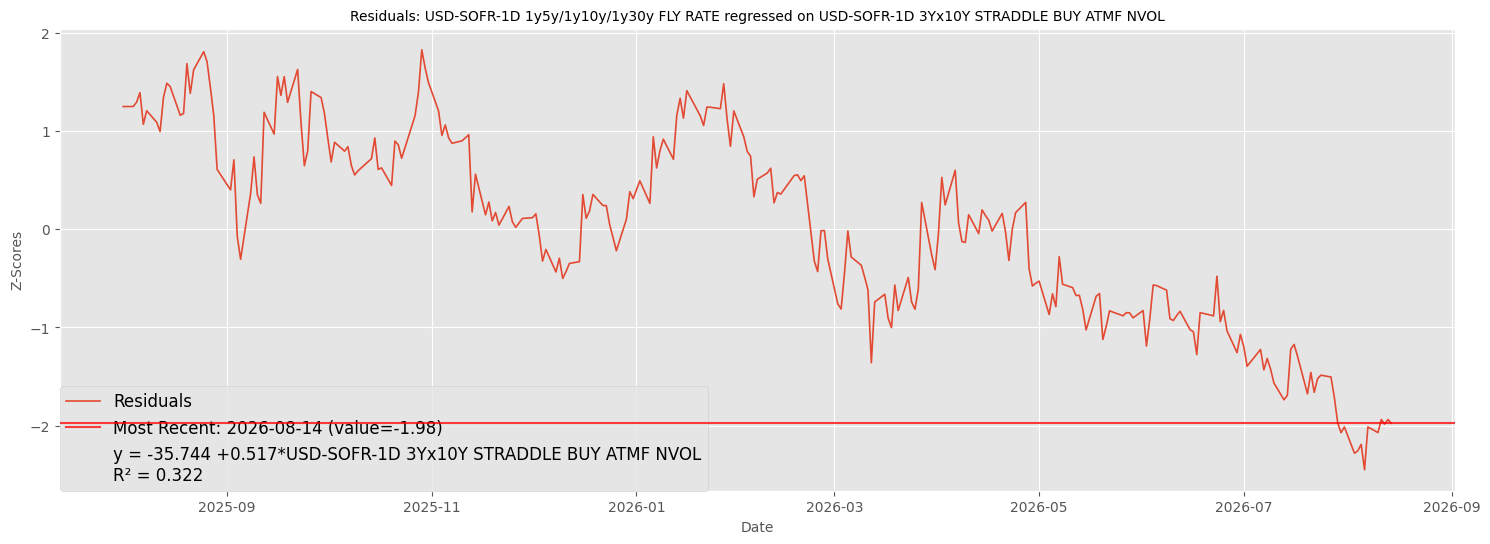

In [28]:
from RVUtils.regression import make_linear_regression_builder

add_indep_var, fit, plot_actual_vs_predicted, plot_residuals_vs_predicted, plot_residuals_timeseries, get_data = make_linear_regression_builder(
    df=df,
    y_col="USD-SOFR-1D 1y5y/1y10y/1y30y FLY RATE",
    date_color_bar=True,
	# on_diff=True
)
add_indep_var("USD-SOFR-1D 3Yx10Y STRADDLE BUY ATMF NVOL")
res = fit(model="OLS", verbose=True)
plot_actual_vs_predicted()
plot_residuals_vs_predicted()
# plot_residuals_timeseries(plot_zscores=True, plot_zero=True, stds=[1, 2], ou_bands=True)
plot_residuals_timeseries(plot_zscores=True, plot_zero=False, ou_bands=False)

In [ ]:
start = NYC_tz.localize(datetime.datetime(2022, 11, 20, 17, 00))
end = NYC_tz.localize(datetime.datetime(2026, 5, 11, 17, 00))
# end = "live" 

df = ts_builder.get_timeseries(
    start=start,
    end=end,
    queries=[
        UnifiedQuery(
			curve="USD-SOFR-1D",
			tenor="CT7/CT20",
			# value=UnifiedValue.IRS_SPREADOVER,
			value=UnifiedValue.IRS_MMSS,
		),
		UnifiedQuery(
			curve="USD-SOFR-1D",
			tenor="CT7/CT20",
			value=UnifiedValue.IRS_SPREADOVER,
		),
		# The outright the seasonality cell below reads. A "20Y" tenor gives the
		# column "USD-SOFR-1D 20Y OUTRIGHT SPREADOVER"; "CT20" would name the
		# column CT20 instead. Same trade either way - SPREADOVER pairs the CT20
		# bond's YTM against a 20Y par swap whichever alias you write.
		UnifiedQuery(
			curve="USD-SOFR-1D",
			tenor="20Y",
			value=UnifiedValue.IRS_SPREADOVER,
		)
		# UnifiedQuery(
		# 	cusip="CT10",
		# 	value=UnifiedValue.FRB_YTM,
		# )
	],
    n_jobs=12,
	  routers={
        "IRS": IRSwapsTB(curve_mdp, show_tqdm=True),
        "FRB": FixedRateBondsTB(usts_mdp, show_tqdm=True),
    },
)
df

# plot, fig, ax, ax2, legend = make_secondary_axis_plot(engine="plotly")
plot, fig, ax, ax2, legend = make_secondary_axis_plot()

plot(
    df["USD-SOFR-1D CT7/CT20 CURVE MMSS"],
    which="left",
    indicators=[
        {"kind": "last", "style": {"linestyle": "--", "linewidth": 1.2, "color": "tab:purple"}},  
        {"kind": "sma", "window": 60, "style": {"linestyle": "--", "color": "green"}},
        {"kind": "simple_avg", "label": "Long-run mean", "style": {"linestyle": "--", "color": "blue"}},
		{"kind": "hurst", "hide": True},
		{"kind": "vol", "returns": "normal", "window": 252, "hide": True},
		{
            "kind": "full_sigma",
            "n": 2,
            "hide_center": True,
            "hide_upper": True,
            "hide_lower": False,
            "style_upper": {"linestyle": "--", "color": "cyan"},
            "style_lower": {"linestyle": "--", "color": "cyan"},
        },
    ],
    # ou={"enable": True, "steps": 126, "add_metrics_to_legend": True}
)
# plot(df["USD-SOFR-1D 10y/30y CURVE RATE"], which="left")
# plot(df["USD-SOFR-1D 30y OUTRIGHT RATE"], which="right")
legend(show_date=True, loc="upper left")
plt.show()

In [ ]:
import re
from RVUtils.seasonality_utils import monthend_cumsum_seasonality

SERIES = "USD-SOFR-1D 20Y OUTRIGHT SPREADOVER"
# SERIES = "USD-SOFR-1D CT7/CT20 CURVE SPREADOVER"
# SERIES = "USD-SOFR-1D CT7/CT20 CURVE MMSS"

if SERIES not in df.columns:
    raise KeyError(
        f"{SERIES!r} is not in df. The cell above decides what is here; add a query for it.\n"
        f"Available: {sorted(df.columns)}"
    )

seasonality_df = monthend_cumsum_seasonality(df[[SERIES]].dropna(), window=10)
display(seasonality_df)

# me_col = "avg"
me_col = "avg-apr"

# A month template only exists once that month has appeared twice, so name the
# miss instead of dying on a bare KeyError three lines later.
templates = [c for c in seasonality_df.columns if c.startswith("avg") and "std" not in c]
if me_col not in seasonality_df.columns:
    raise KeyError(f"{me_col!r} not available for this sample. Templates present: {templates}")

line_w = 1.25
min_op = 0.35
max_op = 0.85
n_last = 12
# A month template is the average of THAT month. Overlaying the last 12
# consecutive months against it compares April to eleven non-Aprils, which is
# not the comparison the template is making. Match the month by default; set
# False for a plain trailing window.
match_template_month = True

monthly_cols = sorted(c for c in seasonality_df.columns if isinstance(c, str) and re.fullmatch(r"\d{4}-\d{2}", c))
m = re.fullmatch(r"avg-([a-z]{3})", me_col)
if match_template_month and m:
    month_num = {n: i for i, n in enumerate(
        ["jan", "feb", "mar", "apr", "may", "jun", "jul", "aug", "sep", "oct", "nov", "dec"], start=1)}[m.group(1)]
    monthly_cols = [c for c in monthly_cols if int(c[5:7]) == month_num]
keep = monthly_cols[-n_last:] if n_last > 0 else []

# keep = ["2024-11", "2023-11", "2022-11", "2021-11", "2020-11"]

fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=seasonality_df.index,
        y=seasonality_df[me_col],
        mode="lines",
        name=f"{me_col}",
        line=dict(color="green", width=3),
    )
)
fig.add_hline(y=0, line_width=0.5, line_dash="dash", line_color="red")
if f"{me_col}+std1" in seasonality_df.columns and f"{me_col}-std1" in seasonality_df.columns:
    fig.add_trace(go.Scatter(x=seasonality_df.index, y=seasonality_df[f"{me_col}+std1"], mode="lines", line=dict(width=0), showlegend=False))
    fig.add_trace(
        go.Scatter(
            x=seasonality_df.index,
            y=seasonality_df[f"{me_col}-std1"],
            mode="lines",
            line=dict(width=0),
            fill="tonexty",
            fillcolor="rgba(0, 255, 0, 0.10)",
            name="±1σ (template)",
        )
    )

# Count the template traces AFTER building them - the band is conditional, so a
# hardcoded 3 silently toggles the wrong traces whenever it is absent.
n_base = len(fig.data)

alphas = np.linspace(min_op, max_op, num=len(keep)) if keep else []
palette = px.colors.qualitative.Dark24 if hasattr(px.colors.qualitative, "Dark24") else px.colors.qualitative.Plotly
for i, col in enumerate(keep):
    fig.add_trace(
        go.Scatter(
            x=seasonality_df.index,
            y=seasonality_df[col],
            mode="lines",
            name=col,  # legend shows 'YYYY-MM'
            opacity=float(alphas[i]),
            line=dict(width=line_w, color=palette[i % len(palette)]),
        )
    )

fig.update_layout(
    xaxis_title=f"BDays from month end  |  template={me_col}",
    yaxis_title=f"Cum Δ, bp  ({SERIES})",
    title=f"Seasonality: {SERIES}  |  template={me_col}  |  {len(keep)} overlaid month(s)",
    showlegend=True,
    template="plotly_dark",
    height=700,
    updatemenus=[
        dict(
            type="buttons",
            showactive=False,
            x=0.01,
            y=1.10,
            xanchor="left",
            yanchor="top",
            buttons=[
                dict(label="Hide months", method="update", args=[{"visible": [True] * n_base + [False] * len(keep)}]),
                dict(label="Show months", method="update", args=[{"visible": [True] * n_base + [True] * len(keep)}]),
            ],
        )
    ],
)
fig.update_xaxes(showspikes=True, spikecolor="white", spikesnap="cursor", spikemode="across", showgrid=True)
fig.update_yaxes(showspikes=True, spikecolor="white", spikesnap="cursor", spikethickness=0.5, showgrid=True)

fig.show(config={"modeBarButtonsToAdd": ["drawline", "drawopenpath", "drawclosedpath", "drawcircle", "drawrect", "eraseshape"]})